# Analisis Regresi Logistik Binomial Pengalaman Menarke

## Outline
- [ 1 - Paket-paket yang digunakan ](#1)
- [ 2 - Uji Regresi Logistik Binomial Perempuan ](#2)
    - [ 2.1 - Uji Regresi ](#2.1)
    - [ 2.2 - Uji Asumsi Regresi Logistik Binomial (Perempuan) ](#2.2)
    - [ 2.3 - Kesimpulan Uji Asumsi dan Kesesuaian Model](#2.3)
    - [ 2.4 - Kesimpulan Uji Regresi Logistik Binomial (Perempuan) ](#2.4)
    - [ 2.5 - Visualisasi Data ](#2.5)
- [ 3 - Uji Regresi Logistik Binomial Laki-laki ](#3)
    - [ 3.1 - Uji Regresi ](#3.1)
    - [ 3.2 - Uji Asumsi ](#3.2)
    - [ 3.3 - Visualisasi Data ](#3.3)
    - [ 3.4 - Kesimpulan ](#3.4)

<a name='1'></a>
## 1 - Paket-paket yang digunakan

Paket-paket berikut digunakan untuk melakukan analisis uji regresi logistik binomial.
- [readxl](https://readxl.tidyverse.org/) digunakan untuk membaca data dari excel ke dalam dataframe R.
- [ggplot2](https://ggplot2.tidyverse.org/) digunakan untuk memplot data.
- [ResourceSelection](https://cran.r-project.org/web/packages/ResourceSelection/index.html) digunakan untuk menghitung probabilitas.
- [broom](https://cran.r-project.org/web/packages/broom/vignettes/broom.html) digunakan untuk merapikan hasil analisis.
- [sjPlot](https://cran.r-project.org/web/packages/sjPlot/index.html) digunakan untuk memvisualisasi data.
- [caret](https://cran.r-project.org/web/packages/caret/index.html) classification and regression training.

In [66]:
suppressPackageStartupMessages({
    library(readxl) 
    library(ggplot2)
    library(ResourceSelection) 
    library(sjPlot)
    library(broom)
    library(car)
    library(caret)
    library(pscl)
    library(IRdisplay)
    library(equatiomatic)
    library(sjPlot)
    library(dplyr)
    library(regplot)
    library(WebPower)
})

In [2]:
df <- read_excel('../data/female_final.xlsx') 

Perintah di atas membaca data excel menggunakan fungsi `read_excel` dari paket `readxl`. Data tersebut disimpan di variabel df. Artinya data yang ada di dalam excel sebelumnya sudah ada di dalam dataframe `df` sehingga untuk mengakses data tersebut kita tidak perlu lagi mengakses file excelnya. 

In [3]:
head(df, 5) 

pengalaman_ms,sumber_informasi,dukungan_sosial,pengalaman_biner,dukungan_biner,sumber_biner
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,3,3,1,1,1
3,3,3,1,1,1
3,3,3,1,1,1
3,3,3,1,1,1
3,3,4,1,1,1


In [5]:
tail(df, 5)

pengalaman_ms,sumber_informasi,dukungan_sosial,pengalaman_biner,dukungan_biner,sumber_biner
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,3,4,1,1,1
3,3,3,1,1,1
3,3,3,1,1,1
3,3,3,1,1,1
3,2,4,1,1,0


Data pengalaman menarke di atas adalah data yang telah diolah dengan menghitung rata-rata masing-masing variabel berdasarkan skor kuesioner. Kemudian skor rata-rata tersebut dikelompokkan ke dalam dua kategori yaitu baik dan tidak baik. Pengelompokan dilakukan dengan mengubah skor 1 & 2 menjadi 0 (tidak baik) dan skor 3 & 4 menjadi 1 (baik). 
Adapun alasannya adalah jawaban yang tidak merata. Terdapat skor yang jumlahnya terlalu sedikit atau bahkan tidak ada sehingga menyebabkan [complete separation](https://stats.oarc.ucla.edu/other/mult-pkg/faq/general/faqwhat-is-complete-or-quasi-complete-separation-in-logistic-regression-and-what-are-some-strategies-to-deal-with-the-issue/). Dengan mereduksi skor menjadi dua (awalnya 4) masalah ini dapat diatasi karena kelompok skor menjadi lebih merata.
- Kolom _pengalaman_ms_, _sumber_informasi_ dan _dukungan_sosial_ berisi skor rata-rata berdasarkan nilai kuesioner masing-masing variabel.
- Kolom _pengalaman_biner_, _dukungan_biner_ dan _sumber_biner_ berisi skor dikotomi (0 dan 1) berdasarkan skor rata-rata masing-masing variabel terkait.
Data tersebut siap untuk dianalisis menggunakan **regresi logistik binomial**.

<a name='2'></a>

## 2 - Uji Regresi Logistik Binomial Perempuan 
Uji regresi dibagi menjadi dua tahap yaitu uji regresi dan uji asumsi. Uji regresi adalah uji utama untuk melihat hubungan antar variabel. Sedangkan uji asumsi adalah uji-uji yang harus dipenuhi agar uji regresi valid secara statisik. 

<a name='2.1'></name>
### 2.1 - Uji Regresi
Uji regresi logistik binomial dilakukan dengan menggunakan fungsi `glm` bawaan dari R. Implementasinya dapat dilihat pada sel di bawah:

In [8]:
model_perempuan <- glm(pengalaman_biner ~ dukungan_biner + sumber_biner,
             data = df,
             family = 'binomial')

summary(model_perempuan)


Call:
glm(formula = pengalaman_biner ~ dukungan_biner + sumber_biner, 
    family = "binomial", data = df)

Coefficients:
               Estimate Std. Error z value Pr(>|z|)    
(Intercept)      1.2120     0.2154   5.627 1.83e-08 ***
dukungan_biner   1.6209     0.2451   6.614 3.73e-11 ***
sumber_biner     0.3329     0.2500   1.332    0.183    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 545.57  on 957  degrees of freedom
Residual deviance: 496.95  on 955  degrees of freedom
AIC: 502.95

Number of Fisher Scoring iterations: 5


<a name='2.2'></a>
### 2.2 - Uji Asumsi Regresi Logistik Binomial (Perempuan)
Uji asumsi harus dilakukan untuk memastikan bahwa hasil uji regresi valid secara statistik sehingga hasilnya dapat dipercaya. Adapun uji-uji yang harus dilakukan adalah sebagai berikut:
1) Independensi Observasi, sudah terpenuhi karena masing-masing responden diambil datanya satu kali (tidak ada yang berulang).
2) Variabel dependen (terikat) harus dalam bentuk biner, sudah terpenuhi karena variabel Y sudah dalam bentuk dua kategori.
3) Linearity of Independent Variables and Log Odds, sudah terpenuhi karena variabel prediktor sudah dalam bentuk biner.
4) Uji Multikolinearitas, uji dilakukan setelah uji regresi.
5) Ukuran sampel besar (The "10-Events-per-Variable" Rule).
6) Uji Outlier, dilakukan setelah model dibuat (uji regresi) menggunakan Cook's Distance atau Bonferroni Outlier Test. 
7) Uji Kecocokan Model, dilakukan setelah model dibuat (setelah uji regresi dilakukan) menggunakan Hosmer-Lemeshow Test.

#### 2.2.1 - Uji Multikolinearitas

In [11]:
vif(model_perempuan)

dukungan_biner   sumber_biner 
      1.012127       1.012127

Nilai 1.01 (sangat jauh di bawah 5) membuktikan bahwa variabel Dukungan Sosial dan Sumber Informasi adalah dua hal yang sepenuhnya independen di lapangan. Mereka tidak saling tumpang tindih.

Berdasarkan hasil pengujian, seluruh variabel independen memiliki nilai Variance Inflation Factor (VIF) di bawah 5. Hal ini menunjukkan tidak adanya masalah multikolinearitas yang serius dalam model regresi, sesuai dengan kriteria yang disarankan oleh (Hair, 2019) bahwa nilai VIF sebaiknya tidak melebihi angka 5.

#### 2.2.2 - Kecukupan Ukuran Sampel
Untuk memastikan bahwa sampel cukup besar, data harus memenuhi asumsi [EPV rule](https://pmc.ncbi.nlm.nih.gov/articles/PMC5394463/) dan [statistical power](https://pmc.ncbi.nlm.nih.gov/articles/PMC3018227/). EPV rule diuji menggunakan Perhitungan Rasio ($Events / k$). Statistical Power diuji dengan Power Analysis (`wp.logistic`).

**1). EPV Rule**

Bertujuan untuk memastikan algoritma komputer (MLE) bisa menghitung angka koefisien yang stabil. EPV dihitung menggunakan rumus berikut:

$\text{EPV} = \frac{\text{Events}}{\text{Variables}}$

Keterangan:
- Events: Jumlah kategori variabel dependen yang paling sedikit. Misalnya antara 0 (tidak baik) dan 1 (baik), jumlah 0 dari total sampel = 50 dan 1 = 100, maka eventsnya adalah kejadian 0.
- Variables: Jumlah variabel independen.
- EPV yang direkomendasikan adalah >10.

In [70]:
epv <- min(table(model_perempuan$y)) / (length(coef(model_perempuan)) - 1)
print(epv)

[1] 39.5


Asumsi kecukupan ukuran sampel dinilai menggunakan kriteria Events Per Variable (EPV). Dengan adanya 2 prediktor dalam model dan frekuensi kategori hasil (outcome) yang paling jarang terjadi, nilai EPV yang dihasilkan adalah 39,5. Angka ini melampaui ambang batas yang direkomendasikan yaitu 10–15 peristiwa per variabel (Peduzzi dkk., 1996), sehingga menjamin stabilitas estimasi maximum likelihood dan meminimalkan risiko bias.

**2). Statistical Power/ Power Analysis**

Bertujuan untuk memastikan penelitian tidak melewatkan efek yang sebenarnya ada (menghindari Type II Error).
Secara teknis, Statistical Power ($1 - \beta$) adalah probabilitas bahwa uji statistik akan menolak hipotesis nol ($H_0$) ketika hipotesis alternatif ($H_a$) adalah benar.$$Power = P(\text{Tolak } H_0 \mid H_a \text{ adalah benar})$$

Adapun tujuan utama dari uji ini adalah:
1) Menghindari "False Negative" (Type II Error)
Tujuan paling krusial adalah memastikan penelitian yang dilakukan tidak berakhir sia-sia. Sering terjadi peneliti menyimpulkan "Variabel X tidak berpengaruh" hanya karena sampelnya terlalu sedikit untuk mendeteksi pengaruh tersebut. Power Analysis memberi tahu kita _apakah hasil yang tidak signifikan terjadi karena memang tidak ada efek, atau karena sampelnya yang kurang_.
3) Menentukan Ukuran Sampel yang Tepat
Jika sampel terlalu kecil, penelitian menjadi spekulatif dan tidak reliabel. Jika sampel terlalu besar, terjadi pemborosan waktu, biaya, dan sumber daya.

**Analogi Sederhana agar mudah dipahami**
Bayangin kita akan menagngkap ikan di danau menggunakan jaring.
- Effect Size adalah ukuran ikan.
- Sample Size adalah lebar jaring.
- Power adalah peluang kita mendapatkan ikan tersebut.

Jika kita ingin menangkap ikan kecil (kecil effect size), tetapi jaring yang kita pakai kecil (sample size rendah), maka peluang mendapatkan ikan sangat rendah (low power). Kita mungkin pulang dengan tangan kosong dan menyimpulkan bahwa "nda ada ikan di danau", padahal masalahnya hanya di jaring yang kita pakai.

Power analisis dapat dilakukan sebelum dan sesudah penelitian:
- Prospective (A Priori): Dilakukan sebelum data diambil. tujuannya untuk menentukan jumlah sampel minimum. 
- Retrospective (Post-hoc): Dilakukan setelah data diambil. Tujuannya untuk melihat seberapa kuat kesimpulan dari hasil yang sudah didapat. (**Ini yang kita lakukan**)

In [68]:
# Mencari p0 dan p1 secara otomatis dari data
tab <- table(df$pengalaman_biner, df$dukungan_biner)
prop_tab <- prop.table(tab, margin = 2) # Proporsi per kolom

p0_data <- prop_tab[2, 1] # Baris ke-2 (Y=1), Kolom ke-1 (X=0)
p1_data <- prop_tab[2, 2] # Baris ke-2 (Y=1), Kolom ke-2 (X=1)

# Masukkan ke dalam fungsi power
wp.logistic(n = nrow(df), p0 = p0_data, p1 = p1_data, family = "Bernoulli")

Power for logistic regression

           p0        p1    beta0    beta1   n alpha     power
    0.8033473 0.9554937 1.407348 1.659251 958  0.05 0.9999986

URL: http://psychstat.org/logistic

#### Interpretasi hasil analisis power:
Nilai Power sebesar 0.9999 (hampir 100%) berarti peluang untuk melakukan Kesalahan Tipe II (Type II Error) hampir nol. Hal ini berarti bahwa jika memang benar ada perbedaan probabilitas dari $0.3$ ke $0.5$ di populasi asli, penelitian ini hampir pasti (99,99%) akan berhasil mendeteksi perbedaan tersebut dan memberikan hasil yang signifikan ($p < 0.05$). Biasanya, angka $0.80$ sudah dianggap cukup. Dengan angka setinggi ini, argumen bahwa "sampel saya sudah cukup" tidak bisa lagi dibantah oleh siapapun.

#### 2.2.3 - Uji Outlier
Uji ini dilakukan untuk mendeteksi ada tidaknya outlier yang dapat mengganggu analisis regresi. Uji dilakukan menggunakan Cook's Distance dan Bonferroni Outlier Test. 

**2.2.3.1 Cook's Distance**

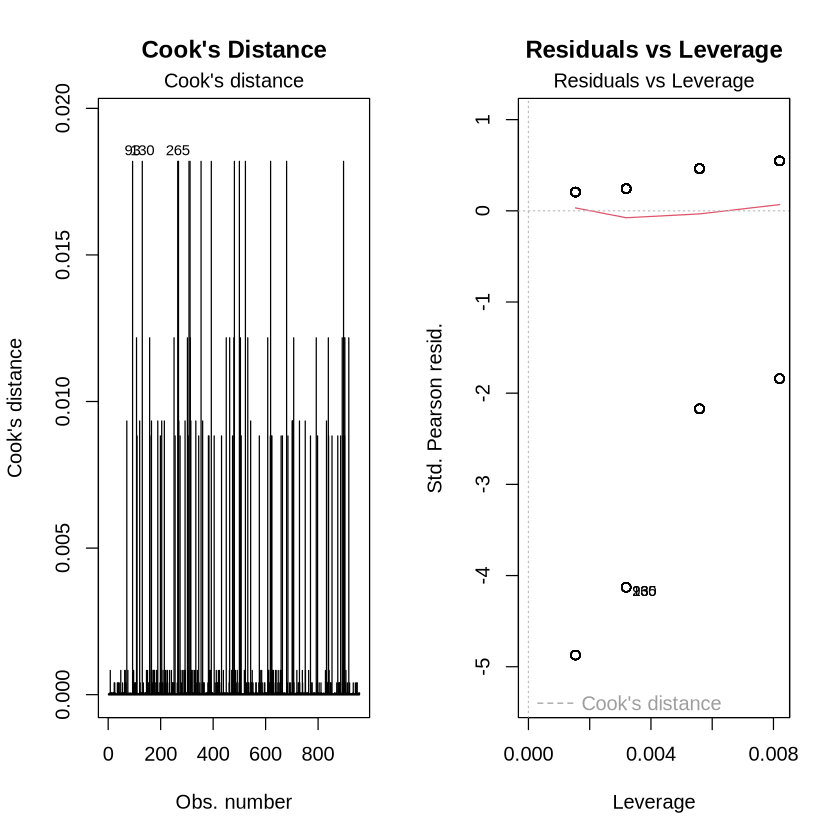

In [78]:
buat_plot <- function() {
  par(mfrow = c(1, 2)) # Layout 2 kolom
  plot(model_perempuan, which = 4, main = "Cook's Distance")
  plot(model_perempuan, which = 5, main = "Residuals vs Leverage")
}

# 2. Tampilkan di layar RStudio (untuk cek hasil)
buat_plot()

1. **Plot Cook's Distance** menunjukkan beberapa poin data yang menjulang tinggi, diantaranya observasi ke 93, 130 dan 265. Namun Perhatikan sumbu Y (Nilai Cook's Distance), angka tertinggi di sumbu Y sebelah kiri. Menurut (Cook & Weisberg, 1995), sebuah observasi baru dianggap "berbahaya" dan wajib dibuang jika nilai Cook's Distance-nya lebih dari 1.0 (atau minimal lebih dari 0.5). Berdasarkan plot di atas, seluruh data sangat jauh di bawah ambang batas bahaya absolute 1.0. Artinya, meskipun data-data tersebut "menarik" garis regresi karena mereka minoritas, tarikan mereka sangat lemah dan tidak merusak hasil analisis.
2. **Pada plot Residuals vs Leverage**, perhatikan sumbu Y (Std. Pearson resid). Ada beberapa titik di bagian bawah yang memiliki nilai residual sangat rendah (mendekati -4 hingga -5), seperti observasi 265.Nilai residual di atas $|3|$ menandakan bahwa untuk baris data tersebut, model melakukan tebakan yang sangat meleset. Secara logika, responden nomor 265 ini memiliki kombinasi profil yang menurut model seharusnya probabilitasnya mendekati 100% untuk satu kategori, tetapi realita datanya menunjukkan kategori sebaliknya. Mereka adalah anomali perilaku di dunia nyata.

3. **Lalu, mengapa observasi 265 yang prediksinya meleset jauh ini tidak merusak model (Cook's Distance-nya tetap kecil)?** Jawabannya ada di sumbu X (Leverage). Nilai leverage tertinggi di data tersebut hanya sekitar 0.008. Ini angka yang sangat mikroskopis. Artinya, meskipun observasi 265 adalah sebuah anomali (residual tinggi), ia tidak memiliki "daya ungkit" (leverage rendah) untuk menarik garis regresi ke arahnya. Ia hanyalah noise yang bisa diabaikan dengan aman oleh model.

In [79]:
png("diagnostik_high_res.png", width = 2400, height = 1200, res = 300)
buat_plot() 
dev.off()

png 
  2

**2.2.3.2 Bonferroni Outlier Test**

Analisis diagnostik dalam penelitian ini tidak hanya berfokus pada stabilitas model secara keseluruhan, tetapi juga pada deteksi anomali data secara individual. Meskipun Cook’s Distance telah digunakan untuk mengidentifikasi observasi berpengaruh (influential cases) yang memiliki potensi untuk membiaskan estimasi koefisien $\beta$, uji ini sering kali kurang sensitif terhadap observasi yang memiliki residu ekstrem namun memiliki leverage rendah. Oleh karena itu, Bonferroni Outlier Test (berdasarkan studentized residuals) dilakukan sebagai langkah komplementer.

In [25]:
# Menjalankan Bonferroni Outlier Test
outlierTest(model_perempuan)

No Studentized residuals with Bonferroni p < 0.05
Largest |rstudent|:
     rstudent unadjusted p-value Bonferroni p
108 -2.539815           0.011091           NA

**Interpretasi**: Uji Bonferroni menunjukkan tidak ada observasi dengan residu yang signifikan secara statistik ($p > 0.05$), dengan residu studentized terbesar ditemukan pada observasi 108 ($r = -2.54, p_{adj} = NA$). Hasil ini melengkapi analisis Cook's Distance (Max $D < 0.02$) yang sebelumnya mengonfirmasi ketiadaan observasi berpengaruh. Kombinasi kedua uji ini membuktikan bahwa model stabil dan tidak bias oleh keberadaan data ekstrem.

#### 2.2.4 - Uji Kelayakan Model (_Goodness of Fit_)
Uji ini menentukan seberapa baik model yang dibentuk memprediksi hasil yang diamati, dengan membandingkan nilai observasi dengan nilai prediksi probabilitas.

Berikut adalah poin-poin penting tujuan Uji Hosmer-Lemeshow:
- Menguji Kelayakan Model: Memastikan apakah model regresi logistik yang digunakan sudah sesuai (fit) dengan data empiris.
- Deteksi Perbedaan: Menguji hipotesis nol ($H_0$) yang menyatakan tidak ada perbedaan signifikan antara model dengan data observasi.
- Validasi Prediksi: Menentukan apakah model mampu memprediksi nilai observasi dengan baik. 

Interpretasi Hasil:
- Signifikansi $p$ > 0,05: Model fit (layak) karena tidak ada perbedaan signifikan antara model dan data observasi ($H_0$ diterima).
- Signifikansi $p$ < 0,05: Model tidak fit (tidak layak) karena terdapat perbedaan signifikan antara model dan data observasi ($H_0$ ditolak). 

In [42]:
hoslem.test(model_perempuan$y, fitted(model), g=10)

Warning message in hoslem.test(model_perempuan$y, fitted(model), g = 10):
“The data did not allow for the requested number of bins.”



	Hosmer and Lemeshow goodness of fit (GOF) test

data:  model_perempuan$y, fitted(model)
X-squared = 1.6419, df = 1, p-value = 0.2001


Dalam statistik, biasanya kita mengejar $p < 0.05$. Namun, pada uji Hosmer-Lemeshow, aturannya terbalik. Di sini, kita justru menginginkan $p\text{-value}$ yang besar (lebih dari 0.05).
- Logikanya: Hipotesis Nol ($H_0$) dalam uji ini adalah "Tidak ada perbedaan antara frekuensi observasi asli dengan frekuensi yang diprediksi oleh model" (dengan kata lain: Model Fit).
- Interpretasi: Karena $p = 0.2001$ ($> 0.05$), Kita gagal menolak $H_0$.
- Kesimpulan: Model memiliki kalibrasi yang baik. Artinya, probabilitas yang diprediksi oleh model sangat mirip dengan kejadian nyata di lapangan. Model tidak "berhalusinasi" dalam menebak peluang menarche.

#### 2.2.5 - McFadden Pseudo-$R^2$
Mengukur seberapa jauh model lebih baik dibandingkan "model kosong" (model yang hanya menebak berdasarkan rata-rata tanpa prediktor).

In [17]:
# Menampilkan Pseudo R-Squared McFadden
pR2(model_perempuan)["McFadden"]

fitting null model for pseudo-r2


McFadden 
0.08912354

Interpretasi Angka 0.089: Dalam ilmu sosial atau kesehatan masyarakat, nilai McFadden antara 0.2 hingga 0.4 sudah dianggap sebagai excellent fit. Nilai 0.089 menunjukkan bahwa prediktor dalam penelitian ini (dukungan sosial dan sumber informasi) memberikan kontribusi yang moderat namun nyata dalam menjelaskan variasi pengalaman menarche. Rasionalitas: Masalah menarche atau kesehatan reproduksi dipengaruhi oleh ribuan faktor (nutrisi, genetika, lingkungan, dll).

<a name='2.3'></a>
### 2.3 - Kesimpulan Uji Asumsi dan Kesesuaian Model
Sebelum menginterpretasikan parameter regresi, serangkaian uji diagnostik dilakukan untuk memastikan stabilitas dan validitas model regresi logistik binomial. Asumsi kecukupan sampel terpenuhi dengan sangat baik, ditunjukkan oleh nilai Events Per Variable (EPV) sebesar 39.5, jauh melampaui batas minimum 10. Selain itu, analisis post-hoc power menunjukkan kekuatan statistik sebesar 0.99, memastikan model memiliki sensitivitas yang sangat tinggi untuk mendeteksi efek yang ada tanpa risiko Type II error.Model juga terbukti stabil dan bebas dari bias observasi ekstrem. Evaluasi Cook’s Distance menunjukkan tidak ada observasi yang memiliki pengaruh dominan (Max $D < 0.02$). Hal ini dikonfirmasi oleh Bonferroni Outlier Test yang menyatakan tidak ada residu studentized yang signifikan secara statistik ($p_{adj} = NA$ untuk residu terbesar). Tidak ditemukan isu multikolinearitas antar prediktor (VIF < 5).Secara keseluruhan, model menunjukkan kalibrasi yang baik berdasarkan uji Hosmer-Lemeshow ($\chi^2(1) = 1.64, p = 0.200$), yang mengindikasikan bahwa frekuensi prediksi model selaras dengan observasi aktual. Nilai McFadden Pseudo-$R^2$ sebesar 0.089 menunjukkan bahwa inklusi variabel dukungan sosial dan sumber daya memberikan kontribusi penjelasan yang bermakna dibandingkan dengan null model.

In [18]:
# Menghitung eksponensial dari koefisien dan selang kepercayaannya
hasil_or <- exp(cbind(OR = coef(model_perempuan), confint(model_perempuan)))
round(hasil_or, 3)

Waiting for profiling to be done...



,OR,2.5 %,97.5 %
(Intercept),3.360,2.231,5.203
dukungan_biner,5.058,3.142,8.237
sumber_biner,1.395,0.848,2.267


<a name='2.4'></a>
### 2.4 - Kesimpulan Hasil Uji Regresi Binomial (Perempuan)
Hasil regresi logistik berganda menunjukkan bahwa variabel Dukungan Sosial (dukungan_biner) memiliki efek positif yang sangat signifikan terhadap probabilitas pengalaman menarche ($\beta = 1.62, z = 6.61, p < 0.001$). Secara spesifik, individu yang memiliki dukungan sosial yang memadai (Adequate) memiliki peluang (odds) 5.06 kali lebih besar untuk mengalami menarche dibandingkan dengan mereka yang tidak memiliki dukungan yang memadai ($OR = 5.06, 95\% \text{ CI: } [3.14, 8.24]$), dengan asumsi ketersediaan sumber daya dikontrol konstan. Sebaliknya, variabel Ketersediaan Sumber Daya (sumber_biner) tidak menunjukkan pengaruh yang signifikan secara statistik pada tingkat $\alpha = 0.05$ ($\beta = 0.33, z = 1.33, p = 0.183$). Meskipun rasio odds menunjukkan tren positif ($OR = 1.40$), interval kepercayaan 95% mencakup angka 1 ($95\% \text{ CI: } [0.85, 2.27]$), yang berarti tidak cukup bukti empiris dalam sampel ini untuk menyimpulkan bahwa sumber daya secara independen memengaruhi pengalaman menarche ketika dukungan sosial telah diperhitungkan.

<a name='2.5'></a>
### 2.5 - Visualisasi Data

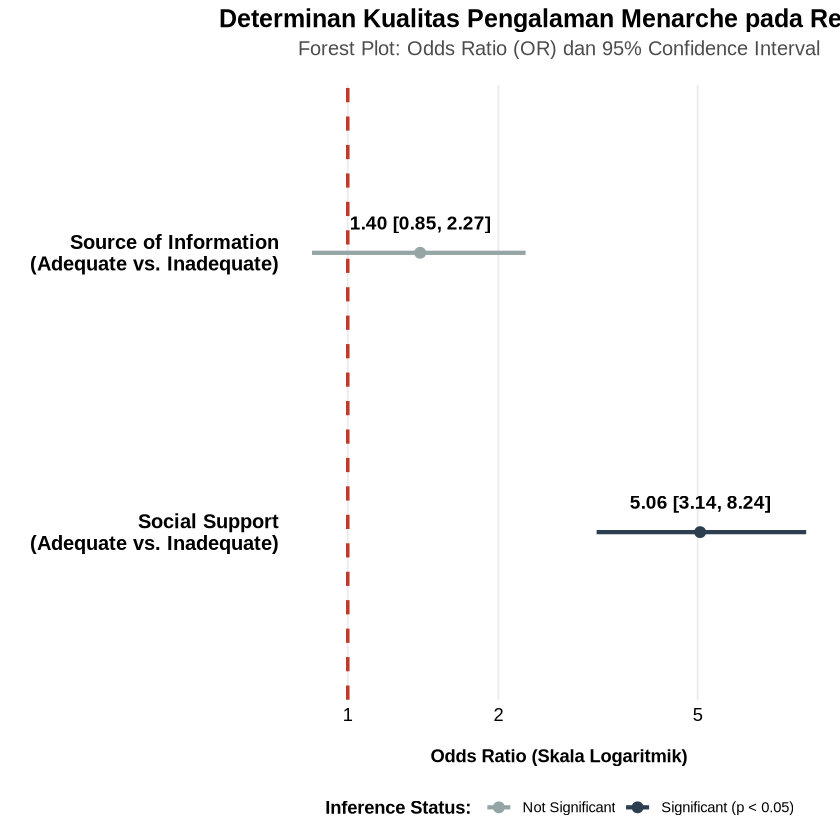

In [59]:
# 2. Ekstraksi hasil matematis model menjadi tabel yang rapi (Tidy Data)
# Argumen 'exponentiate = TRUE' otomatis mengubah log-odds menjadi Odds Ratio
hasil_model <- tidy(model_perempuan, exponentiate = TRUE, conf.int = TRUE)

# 3. Manipulasi Data untuk Visualisasi
data_plot <- hasil_model %>%
  # Kita membuang Intercept karena tidak diinterpretasikan dalam Forest Plot inferensi
  filter(term != "(Intercept)") %>%
  mutate(
    # Merapikan nama variabel agar elegan di sumbu Y
    Variabel = case_when(
      term == "dukungan_biner" ~ "Social Support\n(Adequate vs. Inadequate)",
      term == "sumber_biner" ~ "Source of Information\n(Adequate vs. Inadequate)",
      TRUE ~ term
    ),
    # Membuat label teks persis di atas garis (OR [Lower, Upper])
    Label_Teks = sprintf("%.2f [%.2f, %.2f]", estimate, conf.low, conf.high),
    # Mengkategorikan warna berdasarkan P-Value (Batas 0.05)
    Signifikan = ifelse(p.value < 0.05, "Significant (p < 0.05)", "Not Significant")
  )

# 4. Merakit Grafik Lapis demi Lapis (The Grammar of Graphics)
plot_forest_female <- ggplot(data_plot, aes(x = estimate, y = Variabel, color = Signifikan)) +
  
  # A. Menambahkan garis vertikal merah di angka 1 (Garis Nol Efek)
  geom_vline(xintercept = 1, linetype = "dashed", color = "#c0392b", size = 1) +
  
  # B. Menggambar rentang Confidence Interval dan titik Odds Ratio
  geom_pointrange(aes(xmin = conf.low, xmax = conf.high), linewidth = 1.2, fatten = 4) +
  
  # C. Menambahkan Teks Angka agar pembaca tidak perlu menebak nilai pastinya
  geom_text(aes(label = Label_Teks), vjust = -1.8, size = 4, color = "black", fontface = "bold") +
  
  # D. KUNCI MATEMATIS: Mengubah sumbu X menjadi skala Logaritmik
  scale_x_log10(breaks = c(0.5, 1, 2, 5, 10)) +
  
  # E. Skema warna elegan (Biru Tua untuk Signifikan, Abu-abu untuk Tidak)
  scale_color_manual(values = c("Significant (p < 0.05)" = "#2c3e50", 
                                "Not Significant" = "#95a5a6")) +
  
  # F. Merapikan teks judul dan sumbu
  labs(
    title = "Determinan Kualitas Pengalaman Menarche pada Remaja",
    subtitle = "Forest Plot: Odds Ratio (OR) dan 95% Confidence Interval",
    x = "Odds Ratio (Skala Logaritmik)",
    y = "",
    color = "Inference:"
  ) +
  
  # G. Menggunakan tema minimalis agar fokus pada data, bukan pernak-pernik
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 15, hjust = 0.5),
    plot.subtitle = element_text(size = 12, hjust = 0.5, color = "gray30", margin = margin(b = 15)),
    axis.text.y = element_text(face = "bold", size = 12, color = "black"),
    axis.text.x = element_text(size = 11, color = "black"),
    axis.title.x = element_text(face = "bold", margin = margin(t = 15)),
    legend.position = "bottom",
    legend.title = element_text(face = "bold"),
    panel.grid.minor = element_blank(),
    panel.grid.major.y = element_blank() # Menghapus garis background horizontal
  )

# 5. Menampilkan Plot
print(plot_forest_female)
# ggsave("forest_female.png", plot = plot_forest_female, width = 10, height = 8, dpi = 300)

In [ ]:
ggsave("forest_plot_hasil.png", plot = p_female, width = 10, height = 8, dpi = 300)